In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import os
from infomap import Infomap

from collections import Counter
from collections import defaultdict
from sklearn.metrics import normalized_mutual_info_score, v_measure_score, jaccard_score

In [ ]:
# Create ground truth labels for 300 nodes
# Each block of 60 nodes belongs to the same community, resulting in 5 communities total
ground_truth = []
for i in range(300):
    ground_truth.append(i // 60)

In [14]:
def get_predicted_labels(predicted_sets, total_nodes, start_at_one=True):
    """
    Converts [{1,2}, {3,4}] into a flat list of community IDs.
    
    Args:
        predicted_sets: Your list of sets from the algorithm.
        total_nodes: Total number of nodes (e.g., 300).
        start_at_one: True if your node IDs are 1-300, False if 0-299.
    """
    # Initialize a list of zeros with the correct length
    labels = [0] * total_nodes
    
    for cluster_id, community_set in enumerate(predicted_sets):
        for node in community_set:
            # If nodes are 1-300, we store them at index 0-299
            node = int(node)  # Ensure node is an integer
            index = node - 1 if start_at_one else node
            # Assign the cluster ID (0, 1, 2...) to that node's position
            if index < total_nodes:
                labels[index] = cluster_id
                
    return labels

In [11]:
def infomap_to_networkx_communities(G):
    im = Infomap(silent=True) 
    mapping = im.add_networkx_graph(G)
    im.run()

    infomap_partition = im.get_modules()
    community_dict = defaultdict(set)
    for node, community in infomap_partition.items():
        community_dict[community].add(mapping[node])
    
    return list(community_dict.values())

In [36]:
def set_color_nodes(communities,G):
    colors=plt.cm.jet(np.linspace(0,1,len(communities))) ## Get the colors for the communities
    community_node={} ## Dictionary to store the community of each node
    count_community=0 ## Counter for the communities' labels

    for community in communities: ## For each community
        for node in community: ## For each node in the community
            community_node[node]=count_community ## Store the label of the community of the node
        count_community=count_community+1 ## Update the counter

    color_nodes=[] ## List to store the color of each node
    for node in G.nodes():  
        color_nodes.append(colors[community_node[node]]) ## Get the color of the node

    return color_nodes


In [40]:
def detect_communities(algorithm):
	base_path = "./A3_synthetic_networks/"
	prr_values = np.arange(0.00, 1.01, 0.02)

	n_plots = len(prr_values)
	cols = 5 
	rows = int(np.ceil(n_plots / cols))

	# Increase figsize because network plots need more room than bar charts
	fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
	axes = axes.flatten()

	# --- Main Processing Loop ---
	# for all
	# for i, val in enumerate(prr_values):
	for i, val in  enumerate([0.02, 0.16, 1.00]): # Show only there three
		formatted_val = f"{val:.2f}"
		file_name = f"synthetic_network_N_300_blocks_5_prr_{formatted_val}_prs_0.02.net"
		file_path = os.path.join(base_path, file_name)
		
		ax = axes[i]

		if not os.path.exists(file_path):
			ax.text(0.5, 0.5, f"File Not Found:\n{formatted_val}", ha='center')
			ax.axis('off')
			continue

		# 1. Read the .net file
		G_multi = nx.read_pajek(file_path)
		G = nx.Graph(G_multi)

		# 2. Apply Louvain Community Detection
		if algorithm == 'louvain':
			communities = nx.community.louvain_communities(G, seed=123)
		elif algorithm == 'infomap':
			communities = infomap_to_networkx_communities(G)
		elif algorithm == 'greedy':
			communities = nx.community.greedy_modularity_communities(G)

		num_communities = len(communities)

		# Calculate evaluation metrics
		communities_flat = get_predicted_labels(communities, 300)
		jaccard_score(ground_truth, communities_flat, average='macro')
		v_measure_score(ground_truth, communities_flat)
		nmi = normalized_mutual_info_score(ground_truth, communities_flat, average_method='arithmetic')
		
		# 3. Format the data for visualization
		partition = {}
		for community_id, community in enumerate(communities):
			for node in community:
				partition[node] = community_id

		# 4. Visualize on the specific subplot (ax)
		# Note: spring_layout can be slow; for 50+ plots, 'pos' is calculated per graph
		pos = nx.spring_layout(G, k=0.15, seed=42) 
		# override if val == 1.00 Fruchterman-Reingold representation
		if val == 1.00:
			pos = nx.fruchterman_reingold_layout(G, k=0.5, iterations=50)
		
		
		#cmap = plt.get_cmap('viridis')
		colors = set_color_nodes(communities, G)  # Get colors for nodes based on communities
		# Draw nodes and edges onto the specific 'ax'
		nx.draw_networkx_nodes(G, 
			pos, 
			ax=ax, 
			node_size=20,
			#cmap=cmap, 
			node_color=colors
		)
		nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, edge_color='grey')

		title = (
			f"prr={formatted_val}\n"
			f"{num_communities} communities\n"
			f"Modularity: {nx.community.modularity(G, communities):.3f}\n"
			f"NMI: {nmi:.3f}\n"
			f"Jaccard: {jaccard_score(ground_truth, communities_flat, average='macro'):.3f}\n"
			f"NVI: {v_measure_score(ground_truth, communities_flat):.3f}"
		)
		ax.set_title(title, fontsize=10)
		ax.axis('off') 

	# --- Cleanup ---
	# Remove empty subplots
	for j in range(i + 1, len(axes)):
		fig.delaxes(axes[j])

	plt.tight_layout()

	plt.show()

In [22]:
def represent_degree_distribution(G, ax, scale='linear', rep='bars', weight=False, title=''):
    """Modified to accept an 'ax' argument for grid plotting"""
    if not weight:
        degree_sequence = [G.degree(node) for node in G.nodes()]
    else:
        degree_sequence = [G.degree(node, weight='weight') for node in G.nodes()]
        
    degree_counts = Counter(degree_sequence)
    degrees = list(degree_counts.keys())
    degree_count = list(degree_counts.values())

    if rep == 'bars':
        ax.bar(degrees, degree_count)
    elif rep == 'scatter':
        ax.scatter(degrees, degree_count)
    
    if scale == 'log':
        ax.set_xscale('log')
        ax.set_yscale('log')

    ax.set_xlabel('Degree' if not weight else 'Strength', fontsize=10)
    ax.set_ylabel('#nodes', fontsize=10)
    if title != '':
        ax.set_title(f"prr={title}", fontsize=12)

# Degree Distributions

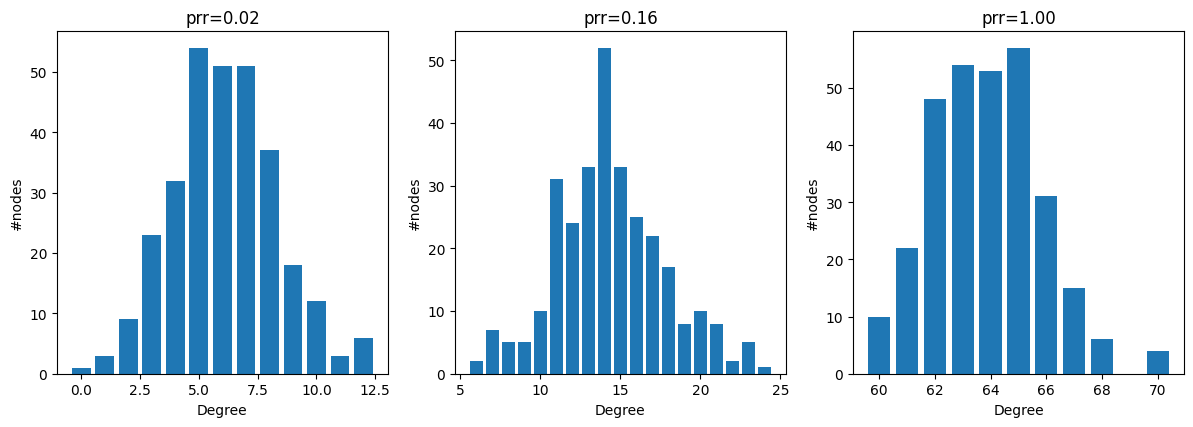

In [23]:
# --- Configuration & Grid Setup ---
base_path = "./A3_synthetic_networks/"
prr_values = np.arange(0.00, 1.01, 0.02)

# Calculate grid dimensions (e.g., 51 values -> 9x6 grid or 17x3)
n_plots = len(prr_values)
cols = 5 
rows = int(np.ceil(n_plots / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()  # Flatten to iterate easily

# --- Main Processing Loop ---
#show all
#for i, val in enumerate(prr_values):
for i, val in  enumerate([0.02, 0.16, 1.00]): # Show only there three
    formatted_val = f"{val:.2f}"
    file_name = f"synthetic_network_N_300_blocks_5_prr_{formatted_val}_prs_0.02.net"
    file_path = os.path.join(base_path, file_name)
    
    ax = axes[i] # Select the current subplot

    if not os.path.exists(file_path):
        ax.text(0.5, 0.5, f"Missing:\n{formatted_val}", ha='center')
        ax.axis('off')
        continue

    # Read and process
    G_multi = nx.read_pajek(file_path)
    G = nx.Graph(G_multi)
    
    represent_degree_distribution(G, ax, scale='linear', rep='bars', title=formatted_val)

# Remove unused empty subplots at the end
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Louvain Algorithm 

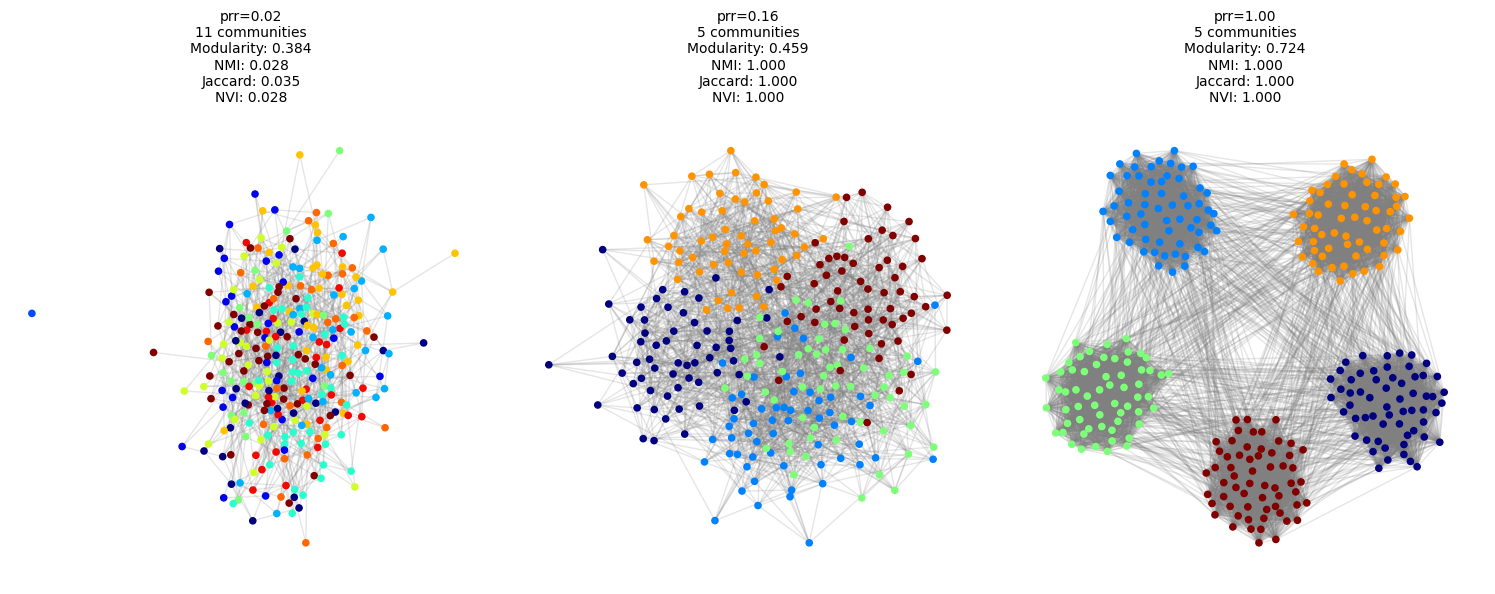

In [41]:
detect_communities('louvain')

# Infomap Algorithm

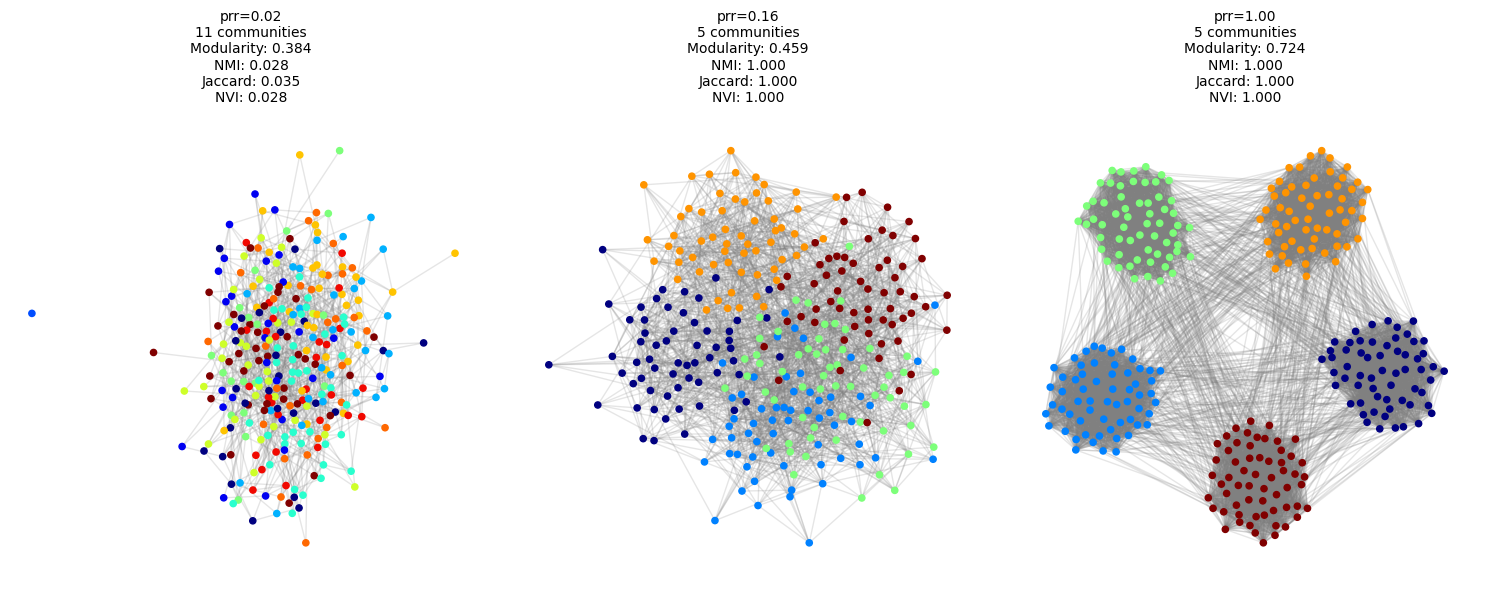

In [42]:
detect_communities('louvain')

# Greedy Algorithm

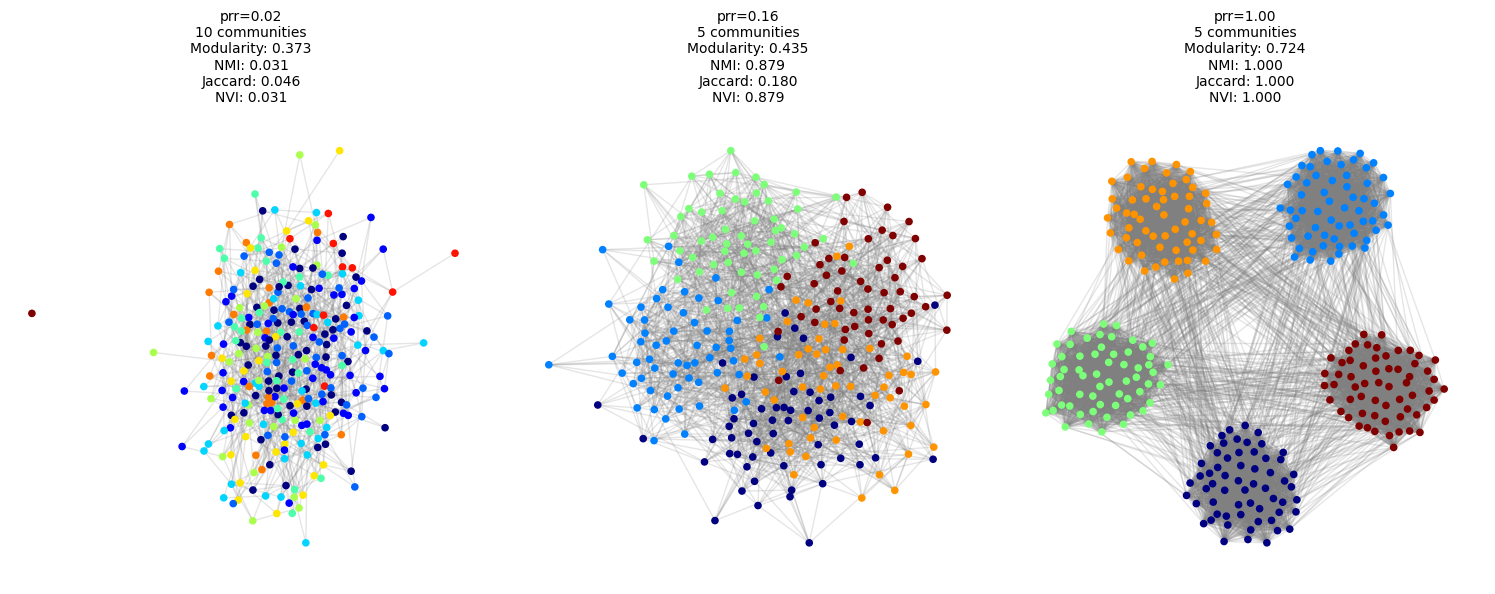

In [43]:
detect_communities('greedy')